In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [20]:
foldername = 'results/20250228/'
pickels = glob.glob(f'{foldername}/*pkl')

df_list = []

for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)
#df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [21]:
df.head()

,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",34271,"[525, 489, 213, 206]",1.005113,"[[588.5277777777778, 656.3611111111111]]",0.984400,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",853,34271.0,...,104.445192,"(588.5277777777778, 656.3611111111111)",218.277347,204.057510,121.143927,115.934163,226.503837,A4-2h-01,A4-2h,1.11
0,"[[False, False, False, False, False, False, Fa...",35006,"[532, 514, 212, 212]",0.993316,"[[543.9166666666666, 584.9166666666666]]",0.983653,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",857,35006.0,...,105.559253,"(543.9166666666666, 584.9166666666666)",219.020547,207.884079,121.556404,117.170771,230.751328,A4-2h-02,A4-2h,1.11
1,"[[False, False, False, False, False, False, Fa...",34344,"[451, 180, 218, 214]",1.001823,"[[558.3333333333333, 196.7777777777778]]",0.983394,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",873,34346.0,...,104.556371,"(558.3333333333333, 196.7777777777778)",221.542321,204.182831,122.955988,116.057572,226.642942,A4-2h-02,A4-2h,1.11
2,"[[False, False, False, False, False, False, Fa...",34529,"[244, 139, 214, 215]",0.999405,"[[334.99999999999994, 304.1111111111111]]",0.983097,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",863,34528.0,...,104.837599,"(334.99999999999994, 304.1111111111111)",216.748702,205.752945,120.295530,116.369734,228.385769,A4-2h-02,A4-2h,1.11
3,"[[False, False, False, False, False, False, Fa...",34426,"[309, 340, 211, 208]",1.012048,"[[334.99999999999994, 370.5833333333333]]",0.975442,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",881,34425.0,...,104.681116,"(334.99999999999994, 370.5833333333333)",229.839074,206.848206,127.560686,116.196039,229.601508,A4-2h-02,A4-2h,1.11


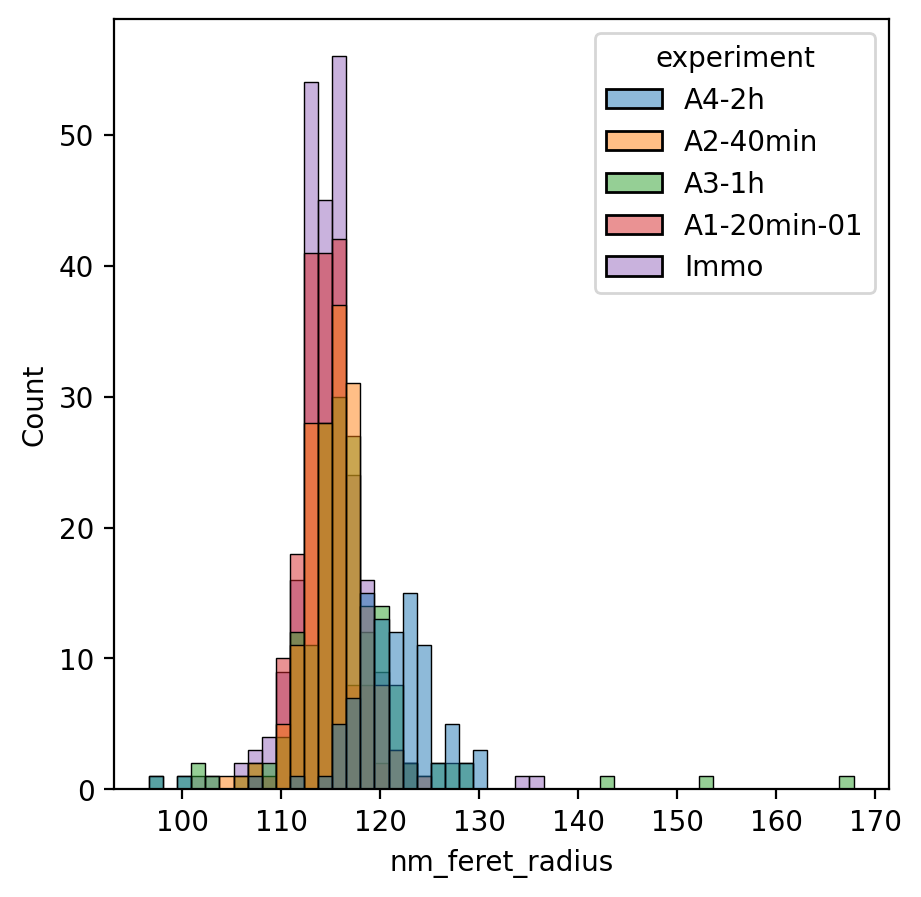

In [22]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [23]:
#exclusion_list = ['A1-01', 'A1-04', 'A1-02', 'B3-01','B2-05','B2-04','B2-03','B2-02'] #20250224
exclusion_list = []

In [24]:
df_filtered = df[~df['img_name'].isin(exclusion_list)]

In [25]:
df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 
                                                                           dp=2, 
                                                                           nm_min_radius=70, 
                                                                           nm_max_radius=150, 
                                                                           nm_per_pixel=x['nm_per_pixel'], 
                                                                           convert_to_nm=True), axis=1)

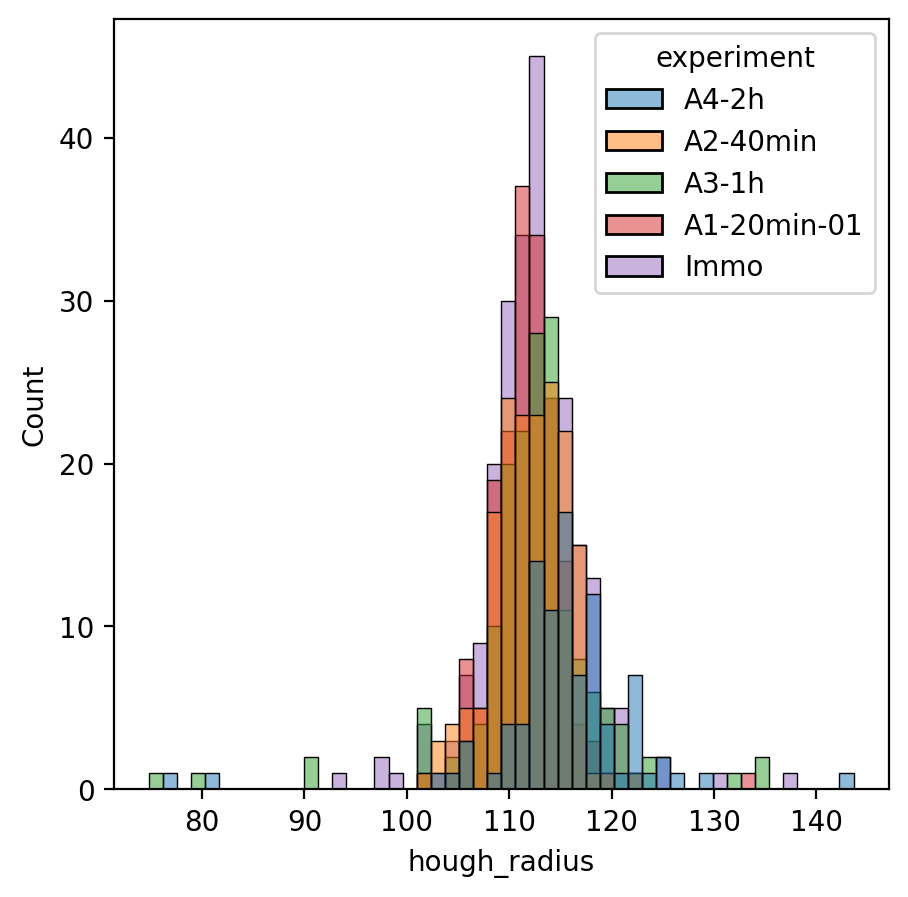

In [26]:
plt.figure(figsize=(5,5), dpi=200)

sns.histplot(data=df_filtered.dropna(), x='hough_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [27]:
filter_quantity =  'hough_radius' 
filter_quantity = 'nm_feret_radius' 
q5, q95 = df_filtered[filter_quantity].quantile([0.05, 0.95])
df_filtered = df_filtered[(df_filtered[filter_quantity] < q95) & (df_filtered[filter_quantity] > q5)]

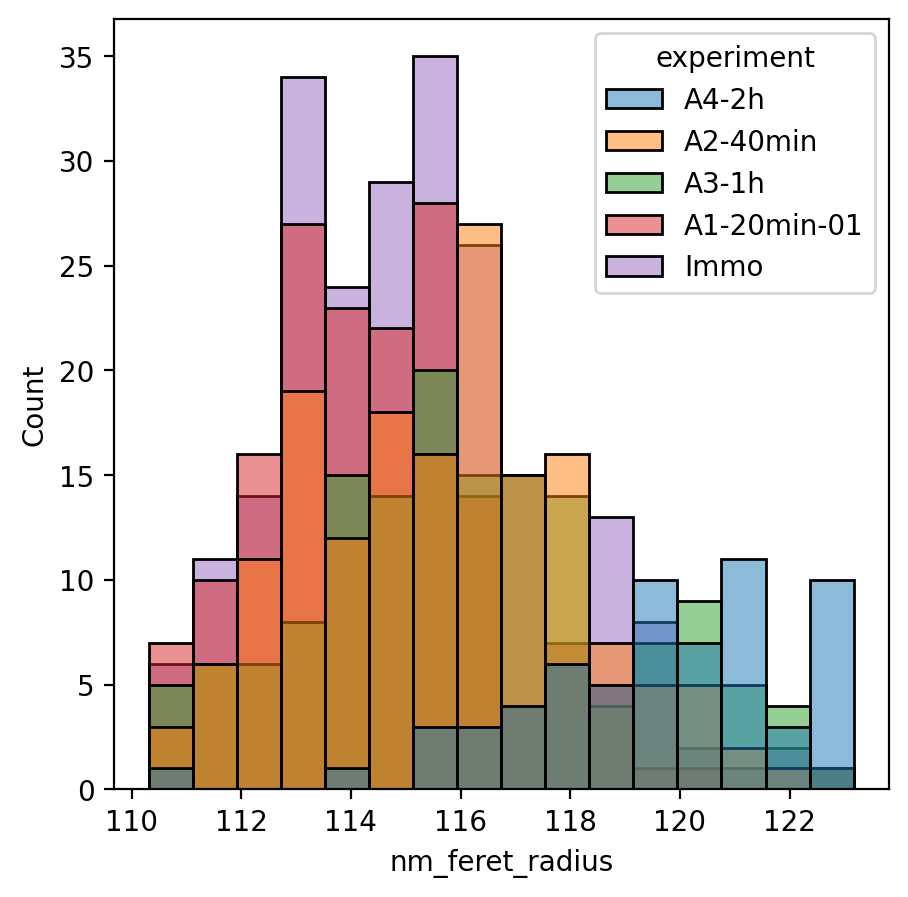

In [28]:
plt.figure(figsize=(5,5), dpi=200)
plot_df = df_filtered.dropna()
sns.histplot(data=plot_df, x=filter_quantity, hue='experiment')
plt.savefig(f'{foldername}/filtered_particle_measurements')

<Figure size 1000x1000 with 0 Axes>

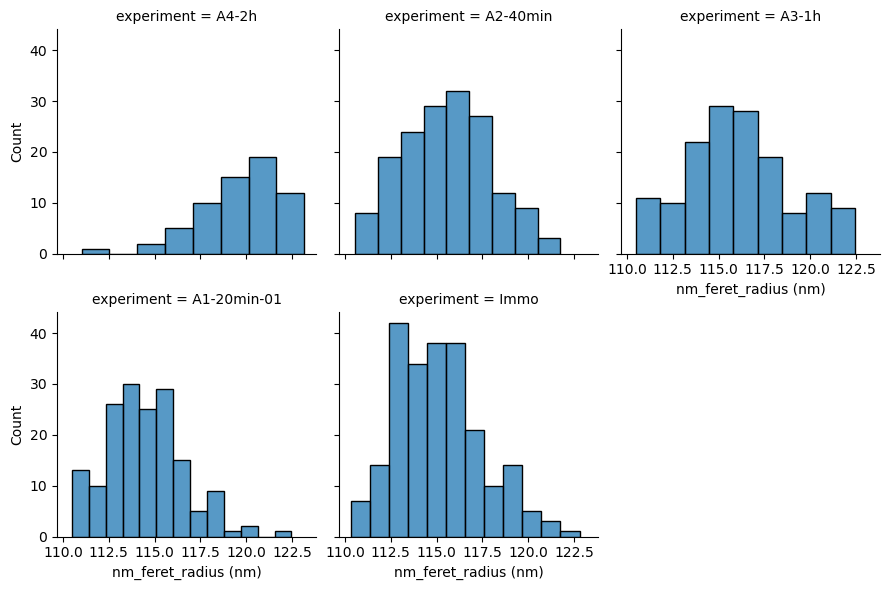

In [29]:
plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, filter_quantity)
g.set_axis_labels(f"{filter_quantity} (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [30]:
filter_quantity =  'hough_radius' 
filter_quantity = 'nm_feret_radius' 
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values=filter_quantity)
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

experiment,A1-20min-01,A2-40min,A3-1h,A4-2h,Immo
0,114.738784,115.488019,115.325207,121.143927,116.382058
1,111.357400,111.245316,118.241053,121.556404,115.119362
2,115.803646,115.963130,115.381283,122.955988,118.642853
3,115.920622,111.593650,117.453002,120.295530,117.955455
4,114.456556,115.024336,111.080446,122.646210,114.986839


In [31]:
experiment_df.describe().to_excel(f'{foldername}/individual-particle-analysis.xlsx')
experiment_df.describe()

experiment,A1-20min-01,A2-40min,A3-1h,A4-2h,Immo
count,166.000000,163.000000,148.000000,64.000000,227.000000
mean,114.458250,115.589850,116.172048,119.655206,115.134031
std,2.091873,2.419938,2.840966,2.444199,2.380559
min,110.488220,110.557895,110.500765,111.013874,110.317723
25%,112.974541,113.639550,114.262289,118.166459,113.297647
50%,114.308441,115.655928,115.946939,119.834988,115.040402
75%,115.621297,117.181255,117.997480,121.277977,116.498192
max,122.465249,121.758956,122.443868,123.167493,122.800651


In [34]:
analysis_df = analyze_samples(experiment_df, 'Immo', alpha=0.01)
analysis_df.to_csv(f'{foldername}/shield-analysis.csv')
analysis_df.to_excel(f'{foldername}/shield-analysis.xlsx')
analysis_df

,A1-20min-01,A2-40min,A3-1h,A4-2h
thickness,-0.675781,0.455819,1.038017,4.521175
CI_lower,-1.262303,-0.183328,0.30667,3.61783
CI_upper,-0.08926,1.094967,1.769364,5.424521
p_value,0.003041,0.065573,0.000279,0.0
significance,Significant,Not significant,Significant,Significant
significance_level,99.5,99.5,99.5,99.5
SEM,0.226553,0.246763,0.281956,0.343963
DOF,377.995843,345.708262,274.920467,99.226212
N_sample,166,163,148,64
N_ref,227,227,227,227


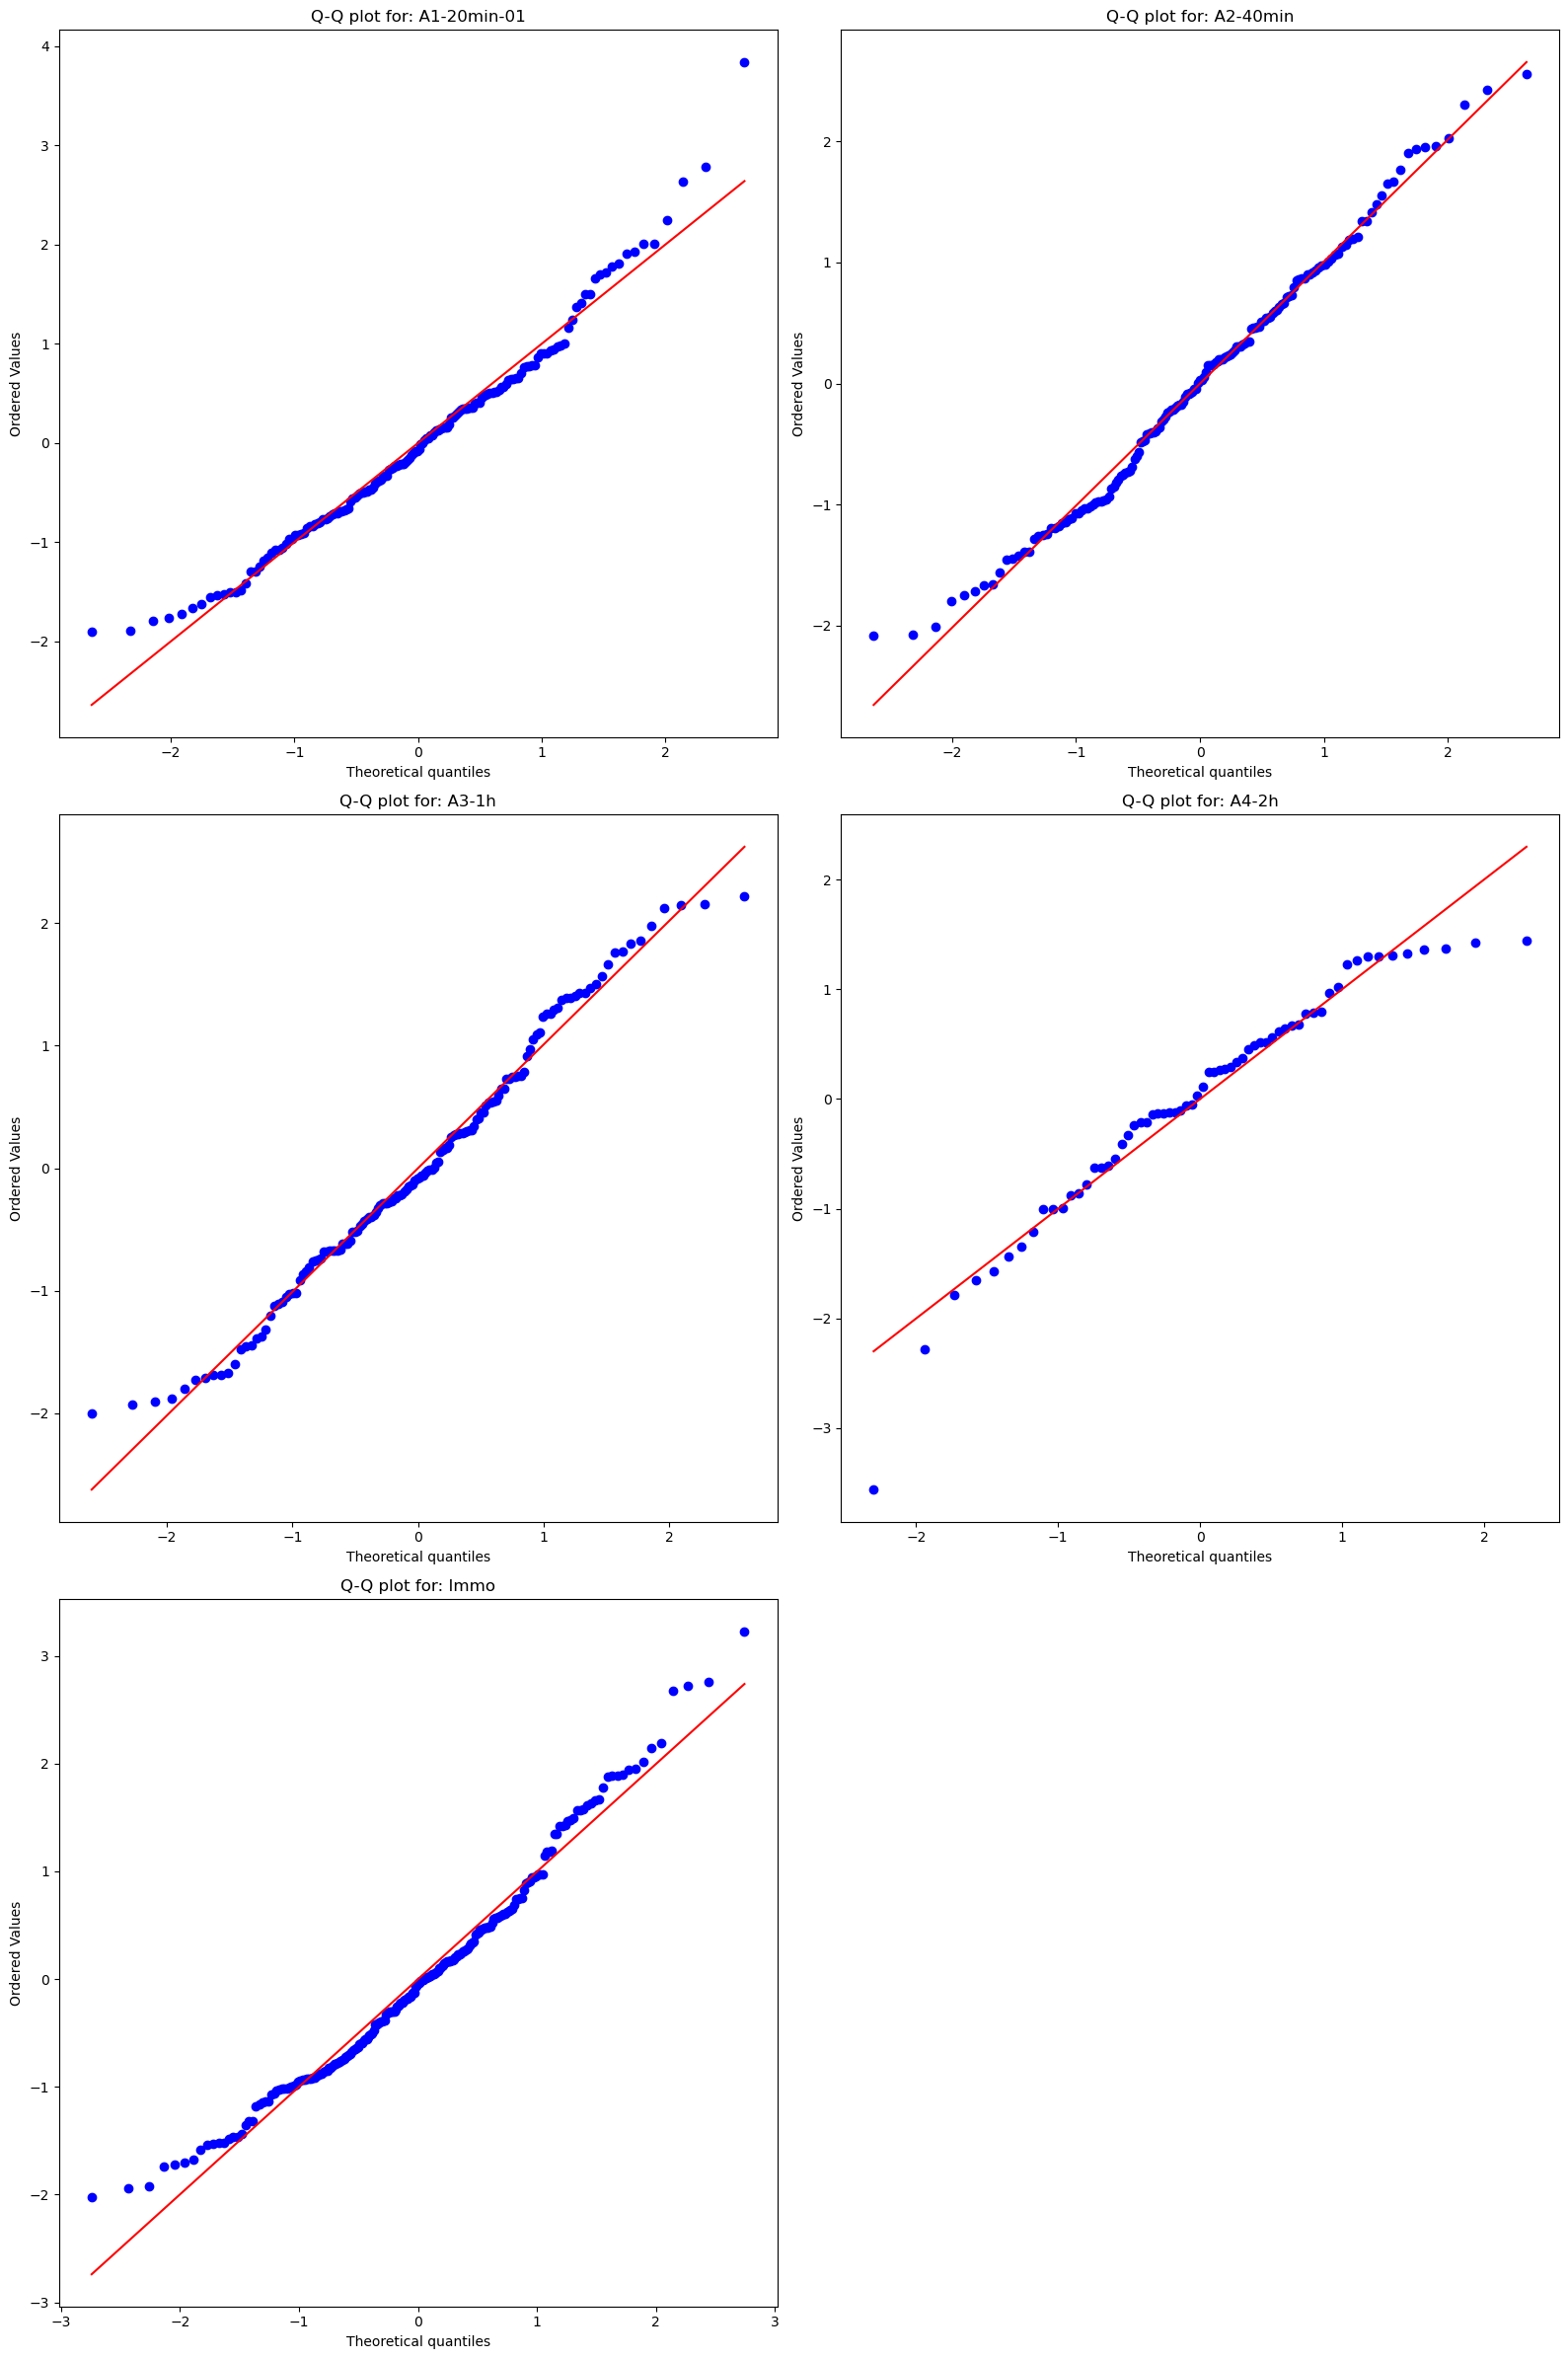

<Figure size 640x480 with 0 Axes>

In [33]:
plot_quantiles(experiment_df, foldername)